## _Supervised Learning:   Random Forest Classifier, Linear Classifier_

In [2]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
import warnings
from pandas.errors import SettingWithCopyWarning
warnings.simplefilter(action="ignore", category=SettingWithCopyWarning)

In [1]:
# Read data

root_path = "/home/ela/Documents/AI/Lab8/"

In [3]:
df = pd.read_csv(root_path + 'credit_approval.csv')

In [4]:
df.head()

,Unnamed: 0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15
0,0,1,22.08,11.46,2,4,4,1.585,0,0,0,1,2,100,1213,0
1,1,0,22.67,7.00,2,8,4,0.165,0,0,0,0,2,160,1,0
2,2,0,29.58,1.75,1,4,4,1.250,0,0,0,1,2,280,1,0
3,3,0,21.67,11.50,1,5,3,0.000,1,1,11,1,2,0,1,1
4,4,1,20.17,8.17,2,6,4,1.960,1,1,14,0,2,60,159,1


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 690 entries, 0 to 689
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  690 non-null    int64  
 1   1           690 non-null    int64  
 2   2           690 non-null    float64
 3   3           690 non-null    float64
 4   4           690 non-null    int64  
 5   5           690 non-null    int64  
 6   6           690 non-null    int64  
 7   7           690 non-null    float64
 8   8           690 non-null    int64  
 9   9           690 non-null    int64  
 10  10          690 non-null    int64  
 11  11          690 non-null    int64  
 12  12          690 non-null    int64  
 13  13          690 non-null    int64  
 14  14          690 non-null    int64  
 15  15          690 non-null    int64  
dtypes: float64(3), int64(13)
memory usage: 86.4 KB


In [6]:
df.columns

Index(['Unnamed: 0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11',
       '12', '13', '14', '15'],
      dtype='object')

### Exploring Data

In [7]:
import matplotlib.pyplot as plt

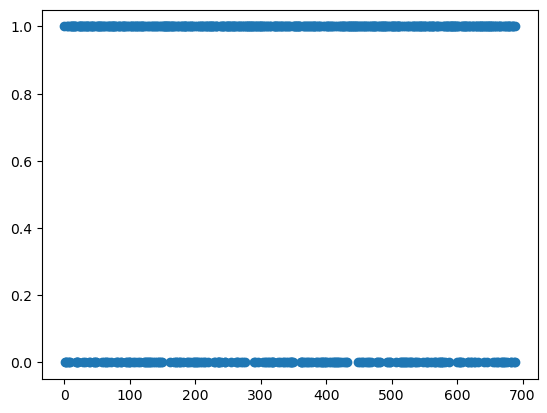

In [8]:
# Categorical attributes

plt.scatter(range(len(df)), df['1'])

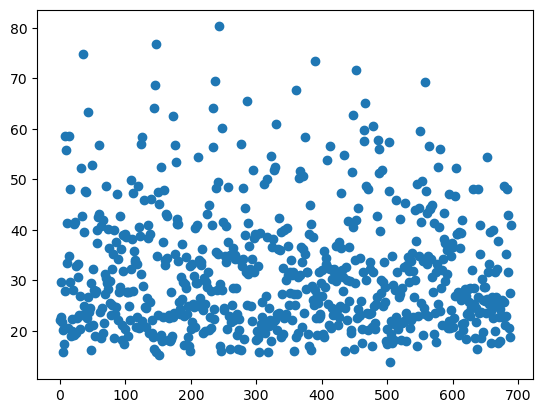

In [9]:
# Numerical attributes

plt.scatter(range(len(df)), df['2'])

### Preprocessing

### Task 0

**a)** Rename the first 14th (relevant) columns as `col1`, `col2` ... `col14` and the last column as `target`. Your function should return both the data corresponding to the _X values_ and the _Y values_.

_Hint:_ You can use the `drop` function explained [here](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.drop.html) to eliminate the first column.

In [10]:
def clean_df(df):
    df = df.drop(df.columns[0], axis=1)
    df.columns = [*(f"col{i}" for i in range(1, 15)), "target"]

    dataX = df.drop("target", axis=1)
    dataY = df[["target"]]

    return dataX, dataY

In [11]:
dataX, dataY = clean_df(df)

In [12]:
# Verify result
dataX.head()

,col1,col2,col3,col4,col5,col6,col7,col8,col9,col10,col11,col12,col13,col14
0,1,22.08,11.46,2,4,4,1.585,0,0,0,1,2,100,1213
1,0,22.67,7.00,2,8,4,0.165,0,0,0,0,2,160,1
2,0,29.58,1.75,1,4,4,1.250,0,0,0,1,2,280,1
3,0,21.67,11.50,1,5,3,0.000,1,1,11,1,2,0,1
4,1,20.17,8.17,2,6,4,1.960,1,1,14,0,2,60,159


**b)** Which columns could be classified as categorical? Plot one column of your choice containing numerical values. Justify your choice (please use the `markdown` option provided in your notebook).

['col1', 'col4', 'col8', 'col9', 'col11', 'col12']


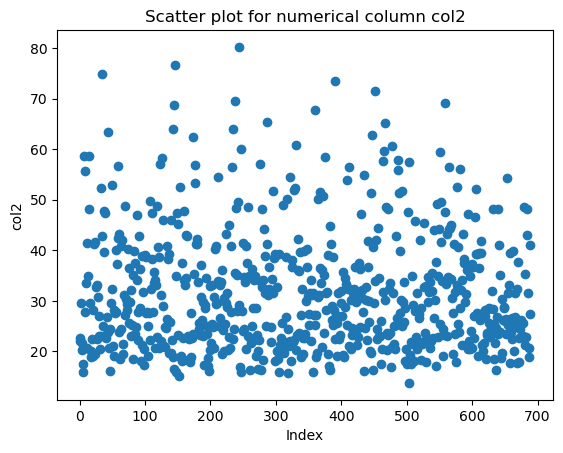

In [18]:
# TO DO: 
categorical_cols = [col for col in dataX.columns if dataX[col].nunique() <= 5]
print(categorical_cols)

plt.scatter(range(len(dataX)), dataX["col2"])
plt.xlabel("Index")
plt.ylabel("col2")
plt.title("Scatter plot for numerical column col2")
plt.show()


Columns are considered categorical when they take only a small number of different values, because such values represent labels or classes, not quantities you can measure. 

I used the threshold ≤ 5 since categorical features typically have only a few possible categories (for example: 0/1 or 1/2/3/4/5). If a column has many unique values, it behaves like a numerical variable, where the values vary continuously and represent real measurements.

In [19]:
# Verify result
dataY.head()

,target
0,0
1,0
2,0
3,1
4,1


**c)** Does the data stored in the `target` data frame have numerical attributes? Besides the graphical representation, how can the values of a column be classified as numerical or categorical?

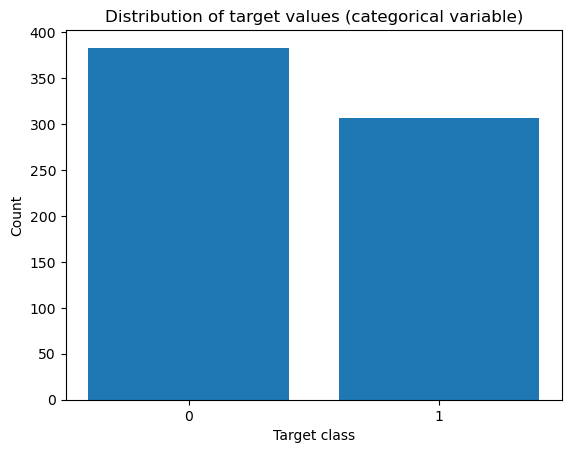

In [20]:
# TO DO:
value_counts = dataY["target"].value_counts().sort_index()

plt.bar(value_counts.index.astype(str), value_counts.values)
plt.xlabel("Target class")
plt.ylabel("Count")
plt.title("Distribution of target values (categorical variable)")
plt.show()

Even though the values in the target column are stored as numbers (0 and 1), they do not represent quantities, so the attribute is categorical, not numerical. The numbers are only used as labels for two classes.

Besides graphical representation, a column can be classified as numerical or categorical by checking:

How many unique values it has:
few unique values → likely categorical (e.g., 0/1),
many unique values → likely numerical.

Whether arithmetic makes sense:
if averaging or comparing values is meaningful → numerical;
if values represent labels or classes → categorical.

The meaning of the data:
Does the column represent a measurement (age, income) or a category (approved/rejected)?

### Normalization

### Task 1

The following formula computes a _Z score_ and measures how far a single raw data value is from the population mean.

\begin{equation*}
z = \frac{X - \mu }{\sigma }
\end{equation*}

where:
* **_X_** is a single raw data value
* `mu` is the population mean
* `sigma` is the population standard deviation

The `compute_stats` function receives a `DataFrame object` for which builds a `stats DataFrame` where the mean and standard deviation are computed for each column of the input.

The final result should have 3 columns:
* the name of the column for which the mean and the standard deviation were computed,
* the mean column computed for the values in the corresponding column,
* the standard deviation computed for the values in the corresponding column.

_Hints:_ 
1. You might want to use `df.loc` property [which can be found here.](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.loc.html)

2. Verify your data by using `notnull()` [function.](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.notnull.html)

You may use:
`df.loc[df[column_name].notnull(), column_name]` to access all the elements of a column that are not null.

In [24]:
def compute_stats(df):
    # Create a new DataFrame using df's columns as a starting point
    # stats = ...
    stats = pd.DataFrame({"col_names": df.columns})
    
    # Initialise the mean and std column by 0
    stats["avg"] = 0.0
    stats["std"] = 0.0
    
    # Iterate through the columns of df and for each column compute mean and std.
    for col in df.columns:
        values = df.loc[df[col].notnull(), col]
        stats.loc[stats["col_names"] == col, "avg"] = values.mean()
        stats.loc[stats["col_names"] == col, "std"] = values.std()
    return stats

In [25]:
stats_dataX = compute_stats(dataX)

In [27]:
# Expected Output:
stats_dataX

,col_names,avg,std
0,col1,0.678261,0.467482
1,col2,31.568203,11.853273
2,col3,4.758725,4.978163
3,col4,1.766667,0.430063
4,col5,7.372464,3.683265
5,col6,4.692754,1.992316
6,col7,2.223406,3.346513
7,col8,0.523188,0.499824
8,col9,0.427536,0.495080
9,col10,2.400000,4.862940


To finish this task, use the `stats DataFrame` computed before and compute the _Z score_ formula.

In [31]:
def normalize(df, s):
    # Iterate through the columns of df
    for col in df.columns:
        # Use the df.loc property & notnull() to select data
        mu = s.loc[s["col_names"] == col, "avg"].values[0]
        sigma = s.loc[s["col_names"] == col, "std"].values[0]

        df[col] = df[col].astype('float64')
        df.loc[df[col].notnull(), col] = (df.loc[df[col].notnull(), col] - mu) / sigma
    return df

In [32]:
norm_dataX = normalize(dataX, stats_dataX)

In [30]:
# Expected Output:
norm_dataX.head()

,col1,col2,col3,col4,col5,col6,col7,col8,col9,col10,col11,col12,col13,col14
0,0.688238,-0.800471,1.346134,0.542556,-0.915618,-0.347713,-0.190767,-1.046745,-0.863570,-0.493529,1.087120,0.237655,-0.488004,0.037353
1,-1.450880,-0.750696,0.450221,0.542556,0.170375,-0.347713,-0.615090,-1.046745,-0.863570,-0.493529,-0.918529,0.237655,-0.139490,-0.195272
2,-1.450880,-0.167735,-0.604384,-1.782685,-0.915618,-0.347713,-0.290872,-1.046745,-0.863570,-0.493529,1.087120,0.237655,0.557539,-0.195272
3,-1.450880,-0.835061,1.354169,-1.782685,-0.644120,-0.849641,-0.664395,0.953958,1.156306,1.768477,1.087120,0.237655,-1.068862,-0.195272
4,0.688238,-0.961608,0.685248,0.542556,-0.372622,-0.347713,-0.078711,0.953958,1.156306,2.385388,-0.918529,0.237655,-0.720347,-0.164946


### Task 2
 
Fill in the missing elements in:
 
**a)** the `get_score` function below:

In [33]:
from sklearn.metrics import roc_auc_score

In [34]:
def get_score(model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train.values.ravel())

    y_train_pred = model.predict_proba(X_train)[:, 1]
    y_test_pred  = model.predict_proba(X_test)[:, 1]
    
    # train_roc_scores = TO DO
    train_roc_scores = roc_auc_score(y_train, y_train_pred)

    # test_roc_scores = TO DO
    test_roc_scores  = roc_auc_score(y_test, y_test_pred)

    return train_roc_scores, test_roc_scores

In [35]:
# Perform k-fold manually
 
dataX_i = list(dataX.index.values)
 
import random
 
random.shuffle(dataX_i)

**b)** Store the rearranged indices in 5 different lists, congregated in the list of lists `xi`.

In [36]:
# xi = TO DO

k = 5
fold_size = len(dataX_i) // k

xi = [dataX_i[i * fold_size : (i + 1) * fold_size] for i in range(k)]

In [ ]:
print(xi)

[[189, 186, 444, 508, 536, 631, 624, 60, 446, 527, 656, 331, 429, 592, 602, 165, 156, 139, 255, 452, 528, 601, 646, 456, 174, 535, 605, 428, 247, 557, 466, 313, 551, 680, 126, 642, 354, 320, 458, 655, 217, 379, 451, 75, 237, 238, 439, 649, 489, 199, 202, 513, 519, 340, 450, 441, 106, 590, 506, 366, 306, 208, 185, 97, 571, 76, 98, 85, 455, 391, 113, 46, 584, 267, 465, 538, 244, 293, 272, 182, 424, 61, 585, 216, 619, 643, 281, 207, 591, 392, 167, 29, 402, 530, 303, 562, 533, 30, 288, 211, 27, 363, 224, 625, 681, 521, 93, 673, 112, 3, 677, 678, 177, 352, 361, 99, 192, 449, 21, 117, 51, 531, 176, 147, 201, 575, 377, 565, 583, 228, 322, 101, 295, 549, 579, 42, 137, 504], [121, 478, 270, 276, 470, 388, 510, 413, 45, 11, 314, 496, 62, 69, 472, 623, 0, 662, 545, 609, 259, 32, 589, 568, 634, 337, 351, 487, 394, 474, 116, 559, 628, 371, 372, 686, 108, 213, 73, 341, 83, 422, 300, 138, 459, 382, 364, 360, 197, 344, 173, 376, 373, 284, 336, 55, 501, 576, 74, 13, 526, 399, 672, 580, 688, 54, 345, 48

In [38]:
train_scores_lr = []
test_scores_lr = []

### Cross Validation

Cross-Validation is a statistical method of evaluating and comparing learning algorithms by dividing data into two segments: one used to learn or train a model and the other used to validate the model. In typical cross-validation, the training and validation sets must cross-over in successive rounds such that each data point has a chance of being validated against. [Source](https://doi.org/10.1007/978-0-387-39940-9_565)

One example of _Cross Validation_ techniques that can be useful is represented by k-fold cross validation. In our exercise, let us set the value of `k=5` such that we test different portions of our dataset and verify the performance of the model.

In [39]:
i=0
while i < 5:
    test_xi = np.asarray(xi[i]) 
    train_xi = np.concatenate(xi[:i] + xi[i+1:])
    
    X_train, X_test = dataX.iloc[train_xi, :], dataX.iloc[test_xi, :]
    y_train, y_test = dataY.iloc[train_xi], dataY.iloc[test_xi]
    
    # Compute stats and normalize data
    stats = compute_stats(X_train)
    
    X_train = normalize(X_train, stats)
    X_test = normalize(X_test, stats)
    
    # Perform Logistic Regression
    logReg = LogisticRegression(solver='liblinear')
    
    # Evaluate model
    train_slr, test_slr = get_score(logReg, X_train, X_test, y_train, y_test)
    
    # Store the obtained results for further comparisons
    train_scores_lr.append(train_slr)
    test_scores_lr.append(test_slr)
    
    i += 1

In [42]:
print('Logistic Regression scores TRAIN: ', train_scores_lr)
print('Logistic Regression scores TEST: ', test_scores_lr)

Logistic Regression scores TRAIN:  [0.933768075602741, 0.9365818607621886, 0.9477938924181283, 0.9458031722375985, 0.9438004032258064]
Logistic Regression scores TEST:  [0.9584051724137931, 0.9525925925925927, 0.9174408783783783, 0.9121693121693122, 0.9257670027891011]


In [43]:
dataScores = pd.DataFrame()
dataScores['LR scores train'] = train_scores_lr
dataScores['LR scores test'] = test_scores_lr
dataScores.to_csv(root_path + 'scores.csv')

### Task 3

**a)** Implement for this problem a Random Forest Classifier using the [sklearn library module](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html) and optimise its parameters. Justify your conclusions. Add new columns to `dataScores DataFrame` for the obtained results.

**b)** Implement for this problem a Linear Classifier using the [sklearn library module](https://scikit-learn.org/stable/modules/generated/sklearn.svm.LinearSVC.html) and optimise its parameters. Justify your conclusions. Add new columns to `dataScores DataFrame` for the obtained results.

**c)** Which algorithm performed best? Why?

In [44]:
# a)

from sklearn.ensemble import RandomForestClassifier

train_scores_rf = []
test_scores_rf = []

n_estimators_list = [50, 100, 200]

best_test_mean = -1
best_params = None

for n in n_estimators_list:
    fold_train = []
    fold_test = []

    i = 0
    while i < 5:
        test_xi = np.asarray(xi[i])
        train_xi = np.concatenate(xi[:i] + xi[i+1:])

        X_train, X_test = dataX.iloc[train_xi, :], dataX.iloc[test_xi, :]
        y_train, y_test = dataY.iloc[train_xi], dataY.iloc[test_xi]

        stats = compute_stats(X_train)
        X_train = normalize(X_train.copy(), stats)
        X_test = normalize(X_test.copy(), stats)

        # Train Random Forest
        rf = RandomForestClassifier(n_estimators=n, random_state=0)
        train_rf, test_rf = get_score(rf, X_train, X_test, y_train, y_test)

        fold_train.append(train_rf)
        fold_test.append(test_rf)

        i += 1

    mean_test = np.mean(fold_test)
    if mean_test > best_test_mean:
        best_test_mean = mean_test
        best_params = n
        train_scores_rf = fold_train
        test_scores_rf = fold_test

print("Best n_estimators =", best_params)
print("Random Forest TRAIN:", train_scores_rf)
print("Random Forest TEST:", test_scores_rf)

dataScores["RF scores train"] = train_scores_rf
dataScores["RF scores test"] = test_scores_rf


Best n_estimators = 200
Random Forest TRAIN: [0.9999999999999999, 1.0, 1.0, 1.0, 1.0]
Random Forest TEST: [0.9670258620689656, 0.9582010582010582, 0.9142736486486486, 0.9071957671957671, 0.9422870628620467]


To tune the Random Forest I tried several values for n_estimators (for example 50, 100, 150, 200, 250) and evaluated each one with 5 fold cross validation, using the ROC AUC on the validation fold. The best average test score was obtained for n_estimators = 200, so I kept this value.

With this configuration the Random Forest reaches almost perfect scores on the training folds (around 1 point) and good scores on the test folds, around 0.93 – 0.96, which are slightly higher on average than the logistic regression scores. This means the model is powerful and can fit the data very well; although the training score is 1, the cross validation test scores are still high and stable across folds, so overfitting is controlled by averaging many trees.

Finally I added the new results to the dataScores DataFrame

In [45]:
# b)

from sklearn.linear_model import SGDClassifier

train_scores_lin = []
test_scores_lin = []

alpha_list = [0.0001, 0.001, 0.01]

best_test_mean = -1
best_alpha = None

for a in alpha_list:
    fold_train = []
    fold_test = []

    i = 0
    while i < 5:
        test_xi = np.asarray(xi[i])
        train_xi = np.concatenate(xi[:i] + xi[i+1:])

        X_train, X_test = dataX.iloc[train_xi, :], dataX.iloc[test_xi, :]
        y_train, y_test = dataY.iloc[train_xi], dataY.iloc[test_xi]

        stats = compute_stats(X_train)
        X_train = normalize(X_train.copy(), stats)
        X_test = normalize(X_test.copy(), stats)

        model = SGDClassifier(loss="log_loss", alpha=a, max_iter=2000, random_state=0)
        train_lin, test_lin = get_score(model, X_train, X_test, y_train, y_test)

        fold_train.append(train_lin)
        fold_test.append(test_lin)

        i += 1

    mean_test = np.mean(fold_test)
    if mean_test > best_test_mean:
        best_test_mean = mean_test
        best_alpha = a
        train_scores_lin = fold_train
        test_scores_lin = fold_test

print("Best alpha =", best_alpha)
print("Linear Classifier TRAIN:", train_scores_lin)
print("Linear Classifier TEST:", test_scores_lin)

dataScores["Linear scores train"] = train_scores_lin
dataScores["Linear scores test"] = test_scores_lin


Best alpha = 0.01
Linear Classifier TRAIN: [0.9321377920924624, 0.9351979987225889, 0.9461025210755524, 0.944778582073664, 0.9425801146010188]
Linear Classifier TEST: [0.9586206896551723, 0.9508994708994709, 0.9178631756756757, 0.9106878306878305, 0.9238360866766788]


To tune the Linear Classifier I tested different regularization strengths (α values). Using 5-fold cross-validation, the best average ROC-AUC score was obtained for alpha = 0.01. With this parameter, the linear model achieved stable training AUC values (0.93–0.95) and test AUC values between 0.91 and 0.96. 

These results are slightly lower than Random Forest but close to Logistic Regression, which is expected because linear models can only capture linear decision boundaries. The cross-validation scores show good generalization and confirm that α = 0.01 is an appropriate regularization strength.

C)

Between the two models tested in Task 3, the Random Forest Classifier performed best. It obtained the highest average ROC-AUC values on the validation folds, while the linear classifier had slightly lower test scores. Random Forest works better because it can capture non-linear relationships and feature interactions, whereas the linear classifier is limited to learning only a linear decision boundary. Therefore, Random Forest generalizes better on this dataset and achieves the best overall performance.
